# Simulating VisiumHD-like data (bin-resolution)

This notebook reproduces the **exact configurations** used to validate
`albis`'s VisiumHD-like, bin-resolution output against real Visium HD data
in the manuscript's Figure 2, at both resolutions Visium HD ships
(compared against the `breast_cancer_visium_hd` and
`human_pancreas_visium_hd` references at 8um and 16um) -- real Visium HD data ships
2um/8um/16um bins from the same underlying capture, so both 8um and 16um are
genuine alternate real configurations, not one replacing the other.

Same low-level API as the other two tutorials in this folder.

## Setup

Install Albis, including plotting support, in your Python environment:

```bash
pip install albis
```

Download this notebook and open it in Jupyter using the same environment.
If Jupyter is not already installed:

```bash
pip install notebook
jupyter notebook
```

If you are already in a notebook, run `%pip install albis` in a cell to
install into the active kernel, then restart the kernel if needed.


In [1]:
from pathlib import Path

import albis as ab
import numpy as np

print("Albis version:", ab.__version__)


Albis version: 0.1.2


`domain_type_mix` is shared by both bin sizes below.

In [2]:
# Manuscript-baseline domain_type_mix (6 domains x 8 cell types). Every domain
# gets a distinct, non-uniform composition -- this is what Figure 2/3's
# domain_true and cell_type_true ground truth is built on. (An alternative
# "strong" mix with much sharper per-domain enrichment exists for dedicated
# domain-recovery test runs, but every Figure 2 count-distribution config uses
# this manuscript-baseline matrix.)
manuscript_domain_type_mix = np.array([
    [0.18, 0.18, 0.13, 0.12, 0.11, 0.10, 0.09, 0.09],
    [0.11, 0.12, 0.18, 0.18, 0.13, 0.10, 0.09, 0.09],
    [0.10, 0.11, 0.12, 0.13, 0.18, 0.18, 0.09, 0.09],
    [0.10, 0.10, 0.11, 0.12, 0.13, 0.13, 0.16, 0.15],
    [0.14, 0.13, 0.12, 0.11, 0.12, 0.13, 0.13, 0.12],
    [0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125],
])


## The exact Figure 2 "bin, 8um" configuration

Same tissue/domain block as the cell and spot tutorials (`sphere_R_um=2050`,
which raises 3D packing so a fixed bin grid isn't mostly empty). The 8um and
16um configurations use identical parameters and the same seed; only
`bin_size_um` differs, so they are the same simulated tissue and every 16um
bin is an exact 2x2 group of 8um bins.

In [3]:
sphere_r_um = 2050.0          # TUNED: raises 3D packing fraction so bins aren't mostly empty

config_bin8 = {
    # ==== 3D tissue geometry and cell placement ====
    "sphere_R_um": sphere_r_um,
    "center": (0.0, 0.0, 0.0),                 # default
    "n_cells": 600_000,                        # manuscript scale
    "allow_cell_overlap": False,               # default
    "cell_radius_kwargs": dict(                # manuscript default (not overridden for bin)
        radius_dist="lognormal", r_mean=7.5, r_sigma=0.28, r_min=4.0, r_max=14.0,
    ),

    # ==== Spatial domains with irregular boundaries (manuscript-wide, all 4 pairings) ====
    "n_domains": 6,
    "core_frac": 0.55,
    "core_bump_amp": 0.25,
    "wedge_angle_amp_deg": 25.0,
    "noise_terms": 16,
    "noise_freq_range": (3.0, 6.0),
    "boundary_fuzz_width_deg": 6.0,
    "boundary_fuzz_flip_prob": 0.15,
    "core_fuzz_width_um": 0.05 * sphere_r_um,  # manuscript ratio: scales with sphere_R_um
    "core_fuzz_flip_prob": 0.25,

    # ==== Cell type composition by domain ====
    "n_cell_types": 8,
    "domain_type_mix": manuscript_domain_type_mix,

    # ==== Gene programs and per-cell gene expression ====
    "marker_genes_per_type": 80,               # default
    "noise_gene_frac": 0.10,                   # default
    "shared_marker_frac": 0.25,                # default
    "base_gene_lognormal": (-2.5, 0.7),        # TUNED: lowers avg. per-cell total counts vs. default (0.7, 0.7)
    "marker_foldchange": 3.5,                  # default
    "shared_marker_foldchange": 2.5,           # default
    "noise_scale": 1.3,                        # TUNED: manuscript "noisy" baseline (default 0.9)
    "cell_size_lognormal": (0.0, 0.35),        # default
    "domain_size_factors": None,               # default (no per-domain expression shift)
    "theta": 2.0,                              # NOT overridden for bin -- manuscript "noisy" default
    "theta_jitter": 0.6,                       # TUNED: 1.0 floors some genes into extreme overdispersion

    # ==== Transcript-level molecule simulation ====
    "inside_prob": 0.95,                       # default
    "assign_k": 8,                             # default

    # ==== Platform-specific capture windows ====
    "xenium_capture_window_um": (12000.0, 24000.0),  # unused for bin output
    "capture_window_um": (6500.0, 6500.0),           # real Visium HD slide window (6.5x6.5mm) -- crops bin output
    "capture_window_center_um": (0.0, 0.0),          # default
    "bin_size_um": 8.0,                              # Visium HD 8um bin grid
    "spot_spacing_um": 100.0,                        # unused for bin output
    "spot_radius_um": 27.5,                          # unused for bin output

    # ==== Slicing, batch effects, and unaligned coordinates ====
    "n_slices": 10,
    "slice_axes": ("Z",),
    "batch_sigma": 0.7,                        # TUNED: per-slice technical batch effect
    "max_deg": 270.0,
    "max_shift": 0.5 * sphere_r_um,            # manuscript ratio: scales with sphere_R_um
    "base_seed_unaligned": 12345,              # default
    "sync_unaligned_seed": True,               # same per-slice misalignment across cell/bin/spot

    # ==== Simulation outputs ====
    "output_modalities": ("bin",),             # bin-resolution aggregation -- the defining choice for "VisiumHD-like"
    "sparse_X": True,                          # default
    "seed": 2025,                              # default
}


> **Runtime warning.** This notebook reproduces the manuscript's actual
> Figure 2 configuration at full scale (**600,000 cells**), not a reduced
> interactive-scale example like `higher_level_api_tutorial.ipynb` /
> `lower_level_api_tutorial.ipynb`. 600,000 cells are simulated at full 3D tissue scale before being aggregated into bins, same cost as the spot tutorial regardless of the much smaller final bin-level `n_obs`. If you just want to see the
> API work end-to-end quickly, drop `n_cells` and `sphere_R_um` down (e.g.
> `n_cells=5000`, proportionally smaller `sphere_R_um`) -- every other
> parameter below is still the exact manuscript value.


In [4]:
sim_bin8 = ab.simulate_3d_molecule_sphere_multires(**config_bin8)

print("top-level keys:", list(sim_bin8.keys()))
adata_bin8 = sim_bin8["bin_adatas"]["Z"]
adata_bin8


top-level keys: ['adata_cell_true', 'adata_cell_obs', 'adata_cell_sectioned', 'bin_adatas', 'spot_adatas', 'meta']


AnnData object with n_obs × n_vars = 6609690 × 556
    obs: 'slice_axis', 'slice_id', 'bin_size_um', 'window_center0', 'window_center1', 'window_size0', 'window_size1', 'plane_dim0', 'plane_dim1', 'cell_type_true', 'domain_true', 'is_empty'
    var: 'gene_class', 'is_noise', 'is_shared_marker'
    uns: 'batch_effect_factors', 'rigid_perturb_inplane'
    obsm: 'spatial', 'cell_type_frac_true', 'domain_frac_true', 'spatial_3d', 'spatial_unaligned', 'spatial_3d_unaligned'
    layers: 'counts_pre_batch'

## Inspect the output

In [5]:
print(adata_bin8)
print()
print("n_obs (observations):", adata_bin8.n_obs)
print("n_vars (genes):", adata_bin8.n_vars)
print("obs columns:", list(adata_bin8.obs.columns))
print("var columns:", list(adata_bin8.var.columns))


AnnData object with n_obs × n_vars = 6609690 × 556
    obs: 'slice_axis', 'slice_id', 'bin_size_um', 'window_center0', 'window_center1', 'window_size0', 'window_size1', 'plane_dim0', 'plane_dim1', 'cell_type_true', 'domain_true', 'is_empty'
    var: 'gene_class', 'is_noise', 'is_shared_marker'
    uns: 'batch_effect_factors', 'rigid_perturb_inplane'
    obsm: 'spatial', 'cell_type_frac_true', 'domain_frac_true', 'spatial_3d', 'spatial_unaligned', 'spatial_3d_unaligned'
    layers: 'counts_pre_batch'

n_obs (observations): 6609690
n_vars (genes): 556
obs columns: ['slice_axis', 'slice_id', 'bin_size_um', 'window_center0', 'window_center1', 'window_size0', 'window_size1', 'plane_dim0', 'plane_dim1', 'cell_type_true', 'domain_true', 'is_empty']
var columns: ['gene_class', 'is_noise', 'is_shared_marker']


In [6]:
summary = ab.describe(adata_bin8)
summary


{'n_obs': 6609690,
 'n_vars': 556,
 'total_counts': 65860258,
 'nonzero_counts': 29560663,
 'platform': None,
 'slice_axis': None,
 'n_slices': 10,
 'slice_ids': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 'obs_columns': ['slice_axis',
  'slice_id',
  'bin_size_um',
  'window_center0',
  'window_center1',
  'window_size0',
  'window_size1',
  'plane_dim0',
  'plane_dim1',
  'cell_type_true',
  'domain_true',
  'is_empty'],
 'var_columns': ['gene_class', 'is_noise', 'is_shared_marker'],
 'layers': ['counts_pre_batch'],
 'obsm_keys': ['spatial',
  'cell_type_frac_true',
  'domain_frac_true',
  'spatial_3d',
  'spatial_unaligned',
  'spatial_3d_unaligned'],
 'uns_keys': ['batch_effect_factors', 'rigid_perturb_inplane'],
 'truth_annotations': ["layers['counts_pre_batch']",
  "obs['cell_type_true']",
  "obs['domain_true']",
  "obsm['cell_type_frac_true']",
  "obsm['domain_frac_true']"]}

### Empirical count dispersion

`generate_simulation_noisy.py` (the manuscript script this notebook mirrors)
fits an empirical per-gene NB dispersion from the pre-batch counts as a sanity
check against real platform data via
`sim_paper/code/count_distribution/count_distribution.py --compare-input`.
Same check here:

In [7]:
def fit_empirical_theta(X):
    """Same method count_distribution.py uses to fit an empirical NB dispersion
    from a count matrix, for comparing against real platform data."""
    if hasattr(X, "multiply"):
        mean = np.asarray(X.mean(axis=0)).ravel()
        mean_sq = np.asarray(X.multiply(X).mean(axis=0)).ravel()
    else:
        mean = X.mean(axis=0)
        mean_sq = (X ** 2).mean(axis=0)
    var = mean_sq - mean ** 2
    overdispersed = var > mean
    theta_hat = mean[overdispersed] ** 2 / (var[overdispersed] - mean[overdispersed])
    theta_hat = theta_hat[np.isfinite(theta_hat) & (theta_hat > 0)]
    return float(np.median(theta_hat)) if theta_hat.size else float("nan")

raw_counts = adata_bin8.layers["counts_pre_batch"] if "counts_pre_batch" in adata_bin8.layers else adata_bin8.X
empirical_theta = fit_empirical_theta(raw_counts)
print(f"empirical theta_hat = {empirical_theta:.3f}")


empirical theta_hat = 0.075


## Plot

`ab.plot()` returns a Matplotlib figure. `coordinates="aligned"` shows the
canonical tissue coordinates (what `domain_true`/`cell_type_true` were
assigned against); `coordinates="unaligned"` shows the per-slice rigid
misalignment `max_deg`/`max_shift` introduce -- the same synthetic
registration-error ground truth used elsewhere in the manuscript.

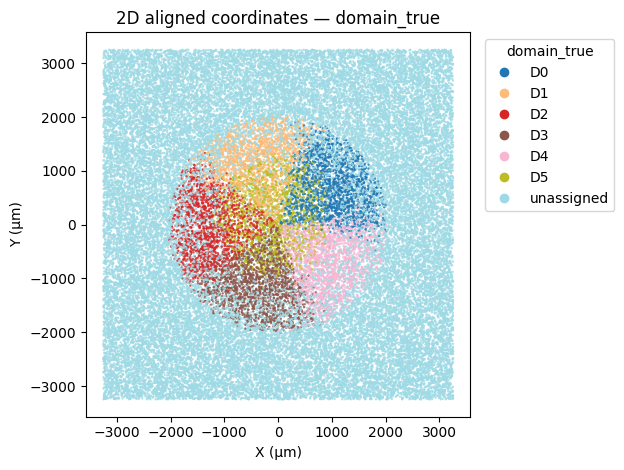

In [8]:
fig = ab.plot(adata_bin8, view="2d", coordinates="aligned", color="domain_true", point_size=3)


### Drop empty bins (QC)

The bin grid tiles the whole 6.5 × 6.5 mm capture window, so bins outside the
tissue capture nothing: they are flagged `obs["is_empty"]` and labelled `unassigned`
above. Dropping them keeps only the tissue. (The manuscript's QC additionally
requires at least 3 detected genes per observation.)

6,609,690 bins -> 1,364,108 after dropping empty bins


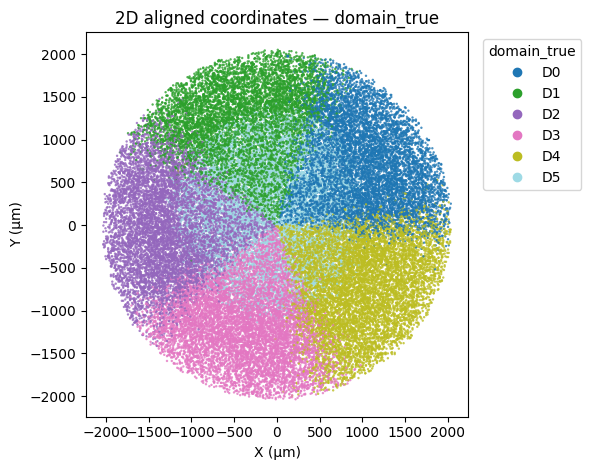

In [9]:
adata_bin8_qc = adata_bin8[~adata_bin8.obs["is_empty"]].copy()
print(f"{adata_bin8.n_obs:,} bins -> {adata_bin8_qc.n_obs:,} after dropping empty bins")
fig = ab.plot(adata_bin8_qc, view="2d", coordinates="aligned", color="domain_true", point_size=3)

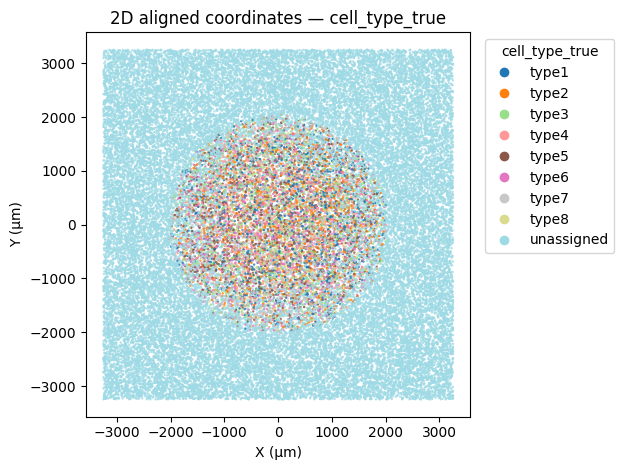

In [10]:
fig = ab.plot(adata_bin8, view="2d", coordinates="aligned", color="cell_type_true", point_size=3)


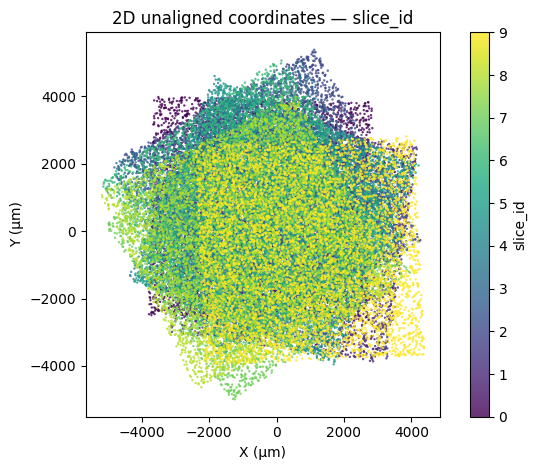

In [11]:
fig = ab.plot(adata_bin8, view="2d", coordinates="unaligned", color="slice_id", point_size=3)


## The exact Figure 2 "bin, 16um" configuration

Only `bin_size_um` changes (8 -> 16). Everything else, including the seed,
is identical to the 8um configuration, so this is the same simulated tissue
aggregated into 16um bins.

In [12]:
config_bin16 = dict(config_bin8)  # same tissue as the 8um config
config_bin16["bin_size_um"] = 16.0  # the 16um Visium HD bin grid

sim_bin16 = ab.simulate_3d_molecule_sphere_multires(**config_bin16)

print("top-level keys:", list(sim_bin16.keys()))
adata_bin16 = sim_bin16["bin_adatas"]["Z"]
adata_bin16


top-level keys: ['adata_cell_true', 'adata_cell_obs', 'adata_cell_sectioned', 'bin_adatas', 'spot_adatas', 'meta']


AnnData object with n_obs × n_vars = 1656490 × 556
    obs: 'slice_axis', 'slice_id', 'bin_size_um', 'window_center0', 'window_center1', 'window_size0', 'window_size1', 'plane_dim0', 'plane_dim1', 'cell_type_true', 'domain_true', 'is_empty'
    var: 'gene_class', 'is_noise', 'is_shared_marker'
    uns: 'batch_effect_factors', 'rigid_perturb_inplane'
    obsm: 'spatial', 'cell_type_frac_true', 'domain_frac_true', 'spatial_3d', 'spatial_unaligned', 'spatial_3d_unaligned'
    layers: 'counts_pre_batch'

## Inspect the output

In [13]:
print(adata_bin16)
print()
print("n_obs (observations):", adata_bin16.n_obs)
print("n_vars (genes):", adata_bin16.n_vars)
print("obs columns:", list(adata_bin16.obs.columns))
print("var columns:", list(adata_bin16.var.columns))


AnnData object with n_obs × n_vars = 1656490 × 556
    obs: 'slice_axis', 'slice_id', 'bin_size_um', 'window_center0', 'window_center1', 'window_size0', 'window_size1', 'plane_dim0', 'plane_dim1', 'cell_type_true', 'domain_true', 'is_empty'
    var: 'gene_class', 'is_noise', 'is_shared_marker'
    uns: 'batch_effect_factors', 'rigid_perturb_inplane'
    obsm: 'spatial', 'cell_type_frac_true', 'domain_frac_true', 'spatial_3d', 'spatial_unaligned', 'spatial_3d_unaligned'
    layers: 'counts_pre_batch'

n_obs (observations): 1656490
n_vars (genes): 556
obs columns: ['slice_axis', 'slice_id', 'bin_size_um', 'window_center0', 'window_center1', 'window_size0', 'window_size1', 'plane_dim0', 'plane_dim1', 'cell_type_true', 'domain_true', 'is_empty']
var columns: ['gene_class', 'is_noise', 'is_shared_marker']


In [14]:
summary = ab.describe(adata_bin16)
summary


{'n_obs': 1656490,
 'n_vars': 556,
 'total_counts': 67310148,
 'nonzero_counts': 26361746,
 'platform': None,
 'slice_axis': None,
 'n_slices': 10,
 'slice_ids': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 'obs_columns': ['slice_axis',
  'slice_id',
  'bin_size_um',
  'window_center0',
  'window_center1',
  'window_size0',
  'window_size1',
  'plane_dim0',
  'plane_dim1',
  'cell_type_true',
  'domain_true',
  'is_empty'],
 'var_columns': ['gene_class', 'is_noise', 'is_shared_marker'],
 'layers': ['counts_pre_batch'],
 'obsm_keys': ['spatial',
  'cell_type_frac_true',
  'domain_frac_true',
  'spatial_3d',
  'spatial_unaligned',
  'spatial_3d_unaligned'],
 'uns_keys': ['batch_effect_factors', 'rigid_perturb_inplane'],
 'truth_annotations': ["layers['counts_pre_batch']",
  "obs['cell_type_true']",
  "obs['domain_true']",
  "obsm['cell_type_frac_true']",
  "obsm['domain_frac_true']"]}

### Empirical count dispersion

`generate_simulation_noisy.py` (the manuscript script this notebook mirrors)
fits an empirical per-gene NB dispersion from the pre-batch counts as a sanity
check against real platform data via
`sim_paper/code/count_distribution/count_distribution.py --compare-input`.
Same check here:

In [15]:
def fit_empirical_theta(X):
    """Same method count_distribution.py uses to fit an empirical NB dispersion
    from a count matrix, for comparing against real platform data."""
    if hasattr(X, "multiply"):
        mean = np.asarray(X.mean(axis=0)).ravel()
        mean_sq = np.asarray(X.multiply(X).mean(axis=0)).ravel()
    else:
        mean = X.mean(axis=0)
        mean_sq = (X ** 2).mean(axis=0)
    var = mean_sq - mean ** 2
    overdispersed = var > mean
    theta_hat = mean[overdispersed] ** 2 / (var[overdispersed] - mean[overdispersed])
    theta_hat = theta_hat[np.isfinite(theta_hat) & (theta_hat > 0)]
    return float(np.median(theta_hat)) if theta_hat.size else float("nan")

raw_counts = adata_bin16.layers["counts_pre_batch"] if "counts_pre_batch" in adata_bin16.layers else adata_bin16.X
empirical_theta = fit_empirical_theta(raw_counts)
print(f"empirical theta_hat = {empirical_theta:.3f}")


empirical theta_hat = 0.133


## Plot

`ab.plot()` returns a Matplotlib figure. `coordinates="aligned"` shows the
canonical tissue coordinates (what `domain_true`/`cell_type_true` were
assigned against); `coordinates="unaligned"` shows the per-slice rigid
misalignment `max_deg`/`max_shift` introduce -- the same synthetic
registration-error ground truth used elsewhere in the manuscript.

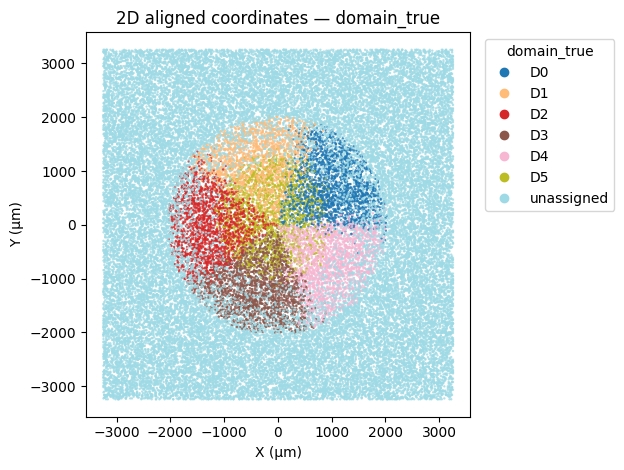

In [16]:
fig = ab.plot(adata_bin16, view="2d", coordinates="aligned", color="domain_true", point_size=3)


### Drop empty bins (QC)

The bin grid tiles the whole 6.5 × 6.5 mm capture window, so bins outside the
tissue capture nothing: they are flagged `obs["is_empty"]` and labelled `unassigned`
above. Dropping them keeps only the tissue. (The manuscript's QC additionally
requires at least 3 detected genes per observation.)

1,656,490 bins -> 374,306 after dropping empty bins


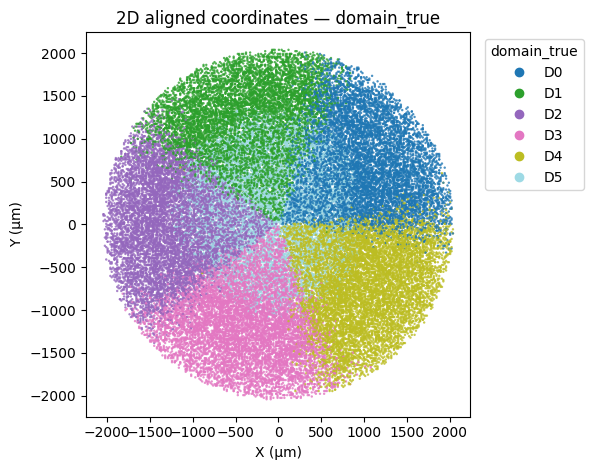

In [17]:
adata_bin16_qc = adata_bin16[~adata_bin16.obs["is_empty"]].copy()
print(f"{adata_bin16.n_obs:,} bins -> {adata_bin16_qc.n_obs:,} after dropping empty bins")
fig = ab.plot(adata_bin16_qc, view="2d", coordinates="aligned", color="domain_true", point_size=3)

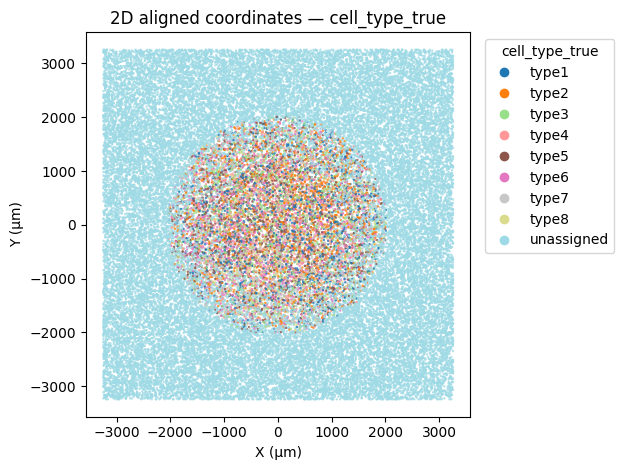

In [18]:
fig = ab.plot(adata_bin16, view="2d", coordinates="aligned", color="cell_type_true", point_size=3)


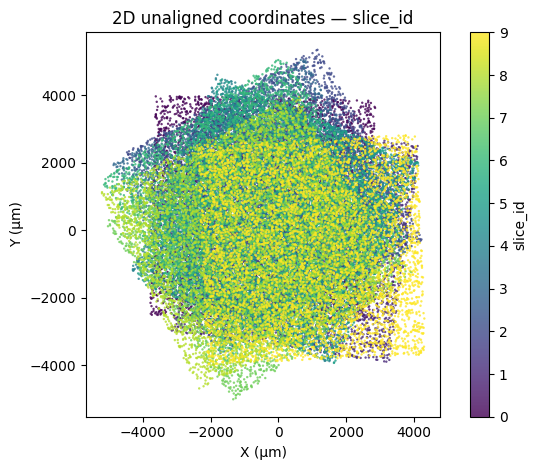

In [19]:
fig = ab.plot(adata_bin16, view="2d", coordinates="unaligned", color="slice_id", point_size=3)


## Save

Same `ab.save(...)` helper as the other two tutorials -- one file per bin
size.

In [20]:
output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

path_bin8 = ab.save(adata_bin8, output_dir / "visiumhd_bin8um_z.h5ad")
path_bin16 = ab.save(adata_bin16, output_dir / "visiumhd_bin16um_z.h5ad")
path_bin8, path_bin16


(PosixPath('outputs/visiumhd_bin8um_z.h5ad'),
 PosixPath('outputs/visiumhd_bin16um_z.h5ad'))